<a href="https://colab.research.google.com/github/nbrrawal/DIY_PROEJCTS/blob/master/Stock_Market__V2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install yfinance
%pip install Prophet

In [24]:
# import modules
from datetime import datetime
import yfinance as yf
import matplotlib.pyplot as plt
# Python
import pandas as pd
from prophet import Prophet

/tmp/ipython-input-1369364465.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('PARADEEP.NS', start = start_date,
[*********************100%***********************]  1 of 1 completed


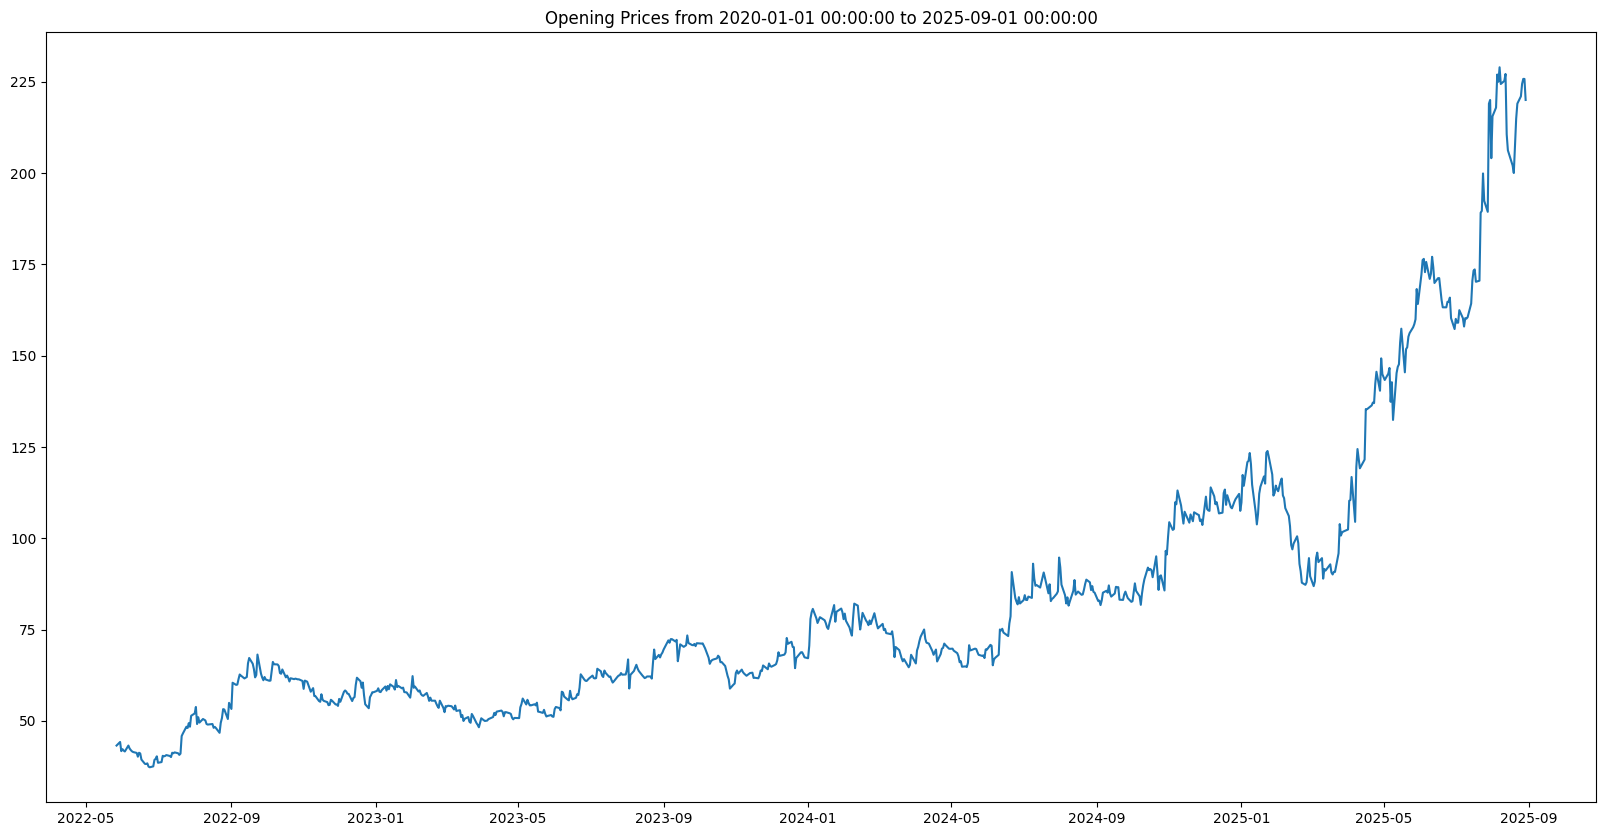

In [6]:

# initialize parameters
start_date = datetime(2020, 1, 1)
end_date = datetime(2025, 9, 1)

# get the data
data = yf.download('PARADEEP.NS', start = start_date,
                   end = end_date)

# display
plt.figure(figsize = (20,10))
plt.title('Opening Prices from {} to {}'.format(start_date,
                                                end_date))
plt.plot(data['Open'])
plt.show()


In [39]:
import yfinance as yf
import pandas as pd

# Example: multiple tickers
tickers = ["AAPL", "MSFT"]

# Download data
data = yf.download(tickers, period="1y", interval="1d")

# If MultiIndex in columns, flatten it
if isinstance(data.columns, pd.MultiIndex):
    data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data.columns]

# Now pick one ticker's Close (e.g., AAPL)
prophet_df = data[['Close_AAPL']].reset_index().rename(columns={"Date": "ds", "Close_AAPL": "y"})

print(prophet_df.head())

/tmp/ipython-input-2277920040.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="1y", interval="1d")
[*********************100%***********************]  2 of 2 completed


          ds           y
0 2024-09-16  215.317917
1 2024-09-17  215.785721
2 2024-09-18  219.667648
3 2024-09-19  227.809753
4 2024-09-20  227.142868


In [51]:
data.columns

Index(['Close_PARADEEP.NS', 'High_PARADEEP.NS', 'Low_PARADEEP.NS',
       'Open_PARADEEP.NS', 'Volume_PARADEEP.NS'],
      dtype='object')

/tmp/ipython-input-1661539922.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("PARADEEP.NS", period="5y", interval="1d")
[*********************100%***********************]  1 of 1 completed
DEBUG:cmdstanpy:input tempfile: /tmp/tmpe0yh3ij1/96axqhoo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpe0yh3ij1/vdu6xc1x.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=20571', 'data', 'file=/tmp/tmpe0yh3ij1/96axqhoo.json', 'init=/tmp/tmpe0yh3ij1/vdu6xc1x.json', 'output', 'file=/tmp/tmpe0yh3ij1/prophet_modelq_2b3uae/prophet_model-20250915173324.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:33:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


ds    datetime64[ns]
y            float64
dtype: object
          ds          y
0 2022-05-27  43.143417
1 2022-05-30  41.374432
2 2022-05-31  41.374432
3 2022-06-01  41.767540
4 2022-06-02  41.374432


17:33:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


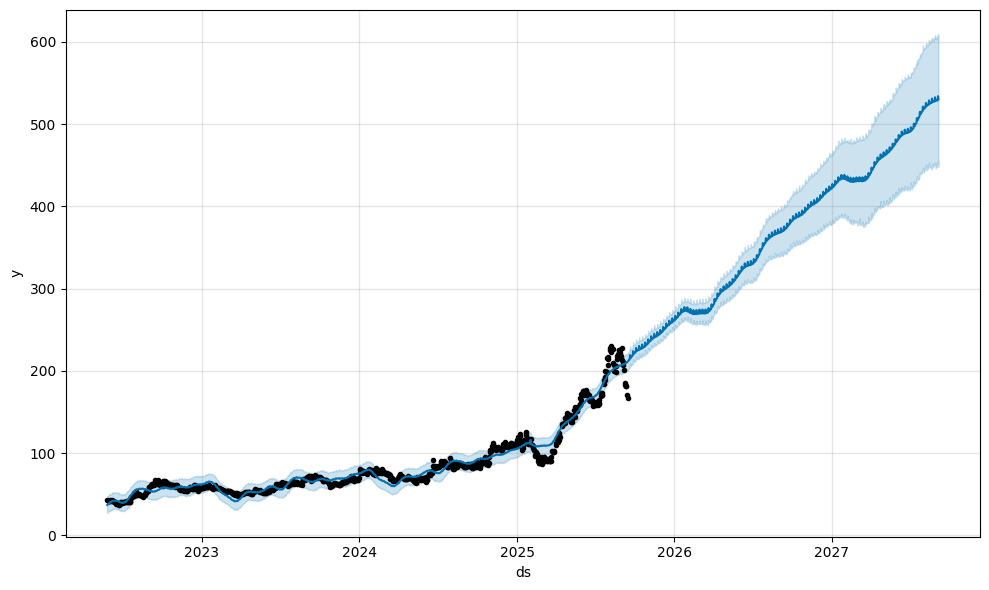

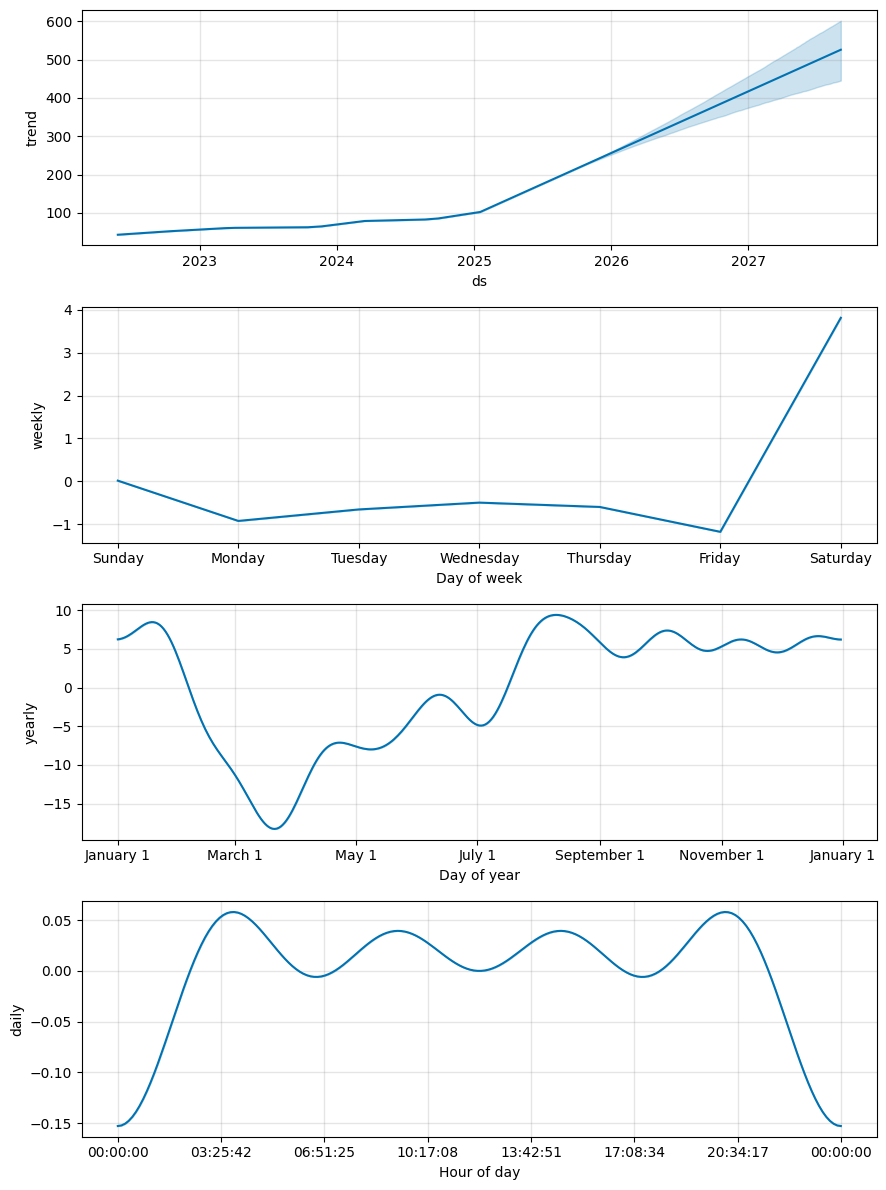

In [57]:
import yfinance as yf
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta

# 1. Download historical data for Apple (AAPL)
data = yf.download("PARADEEP.NS", period="5y", interval="1d")

# 2. If MultiIndex in columns -> flatten
if isinstance(data.columns, pd.MultiIndex):
    data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data.columns]

# 3. Extract Close price, reset index, rename columns
if "Close" in data.columns:
    prophet_df = data[["Close"]].reset_index().rename(columns={"Date": "ds", "Close": "y"})
elif "Close_PARADEEP.NS" in data.columns:
    prophet_df = data[["Close_PARADEEP.NS"]].reset_index().rename(columns={"Date": "ds", "Close_PARADEEP.NS": "y"})
else:
    raise KeyError("Couldn't find Close column in Yahoo Finance data.")

# 4. Ensure correct dtypes
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
prophet_df["y"] = prophet_df["y"].astype(float)
cutoff_date = prophet_df["ds"].max() - relativedelta(months=8)
prophet_df_last5 = prophet_df[prophet_df["ds"] >= cutoff_date].copy()
# 5. Drop missing values
prophet_df = prophet_df.dropna()

print(prophet_df.dtypes)
print(prophet_df.head())

# 6. Initialize and fit Prophet model
model = Prophet(daily_seasonality=True)
model.fit(prophet_df)

# 7. Create future dataframe (predict next 90 days)
future = model.make_future_dataframe(periods=720)
forecast = model.predict(future)

# 8. Plot forecast
fig1 = model.plot(forecast)
plt.show()

# 9. Plot forecast components
fig2 = model.plot_components(forecast)
plt.show()


In [46]:
# Python
m = Prophet()
m.fit(ds)
# Python
future = m.make_future_dataframe(periods=365)
future.tail()

TypeError: arg must be a list, tuple, 1-d array, or Series

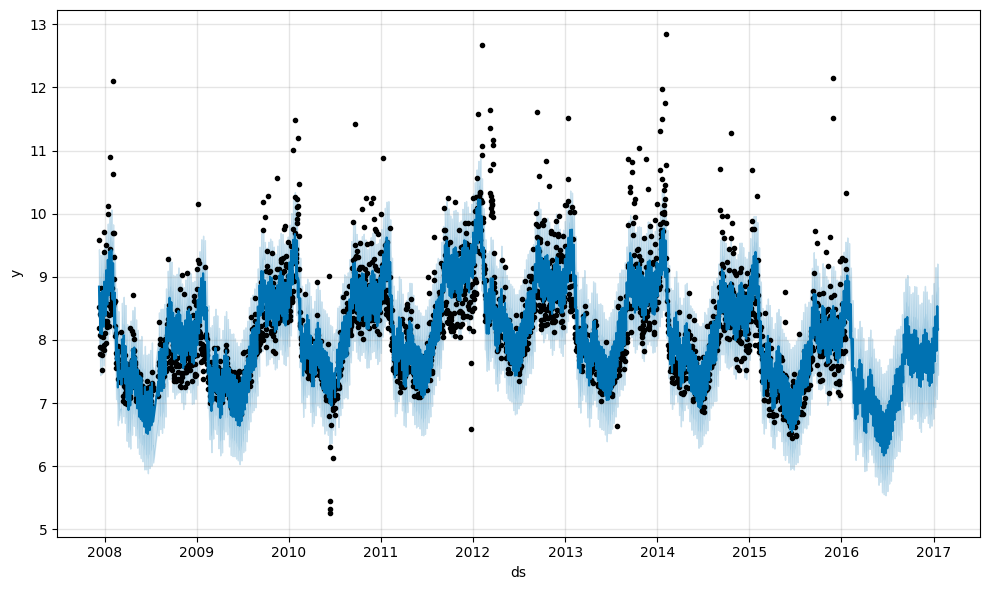

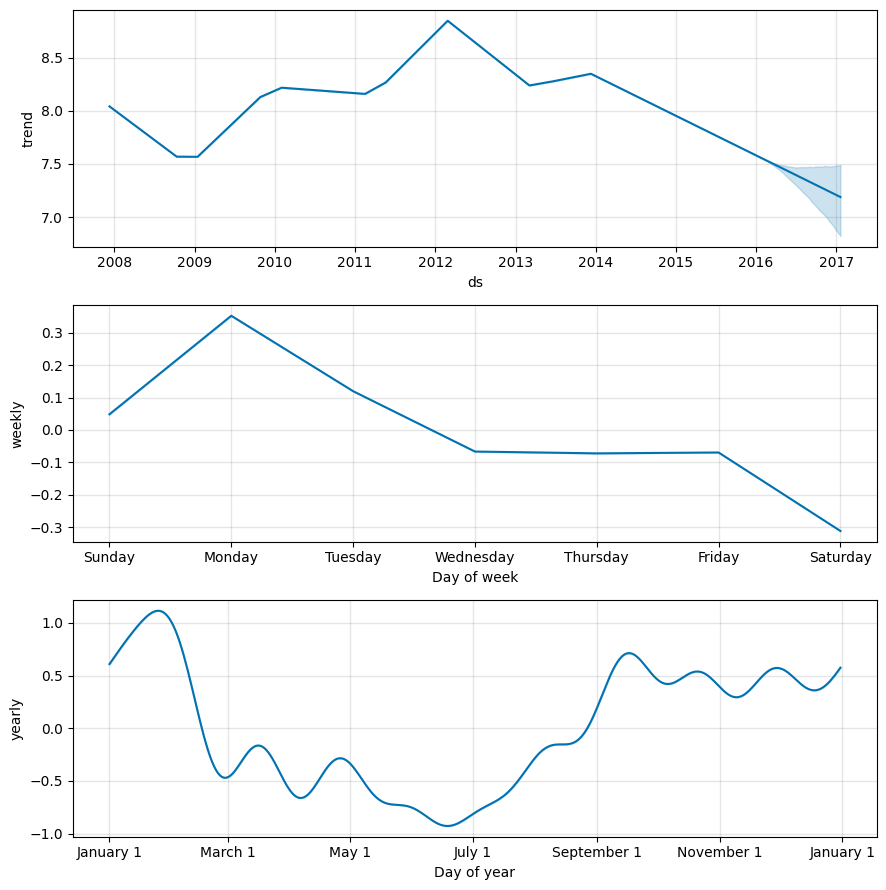

In [ ]:
# Python
fig1 = m.plot(forecast)
# Python
fig2 = m.plot_components(forecast)